# XCat neighbourhood diagnostics

Inspects the SemEval-2015/2016 Restaurants category labels and the XCat
neighbourhood structure they imply: category distribution, train/test
category overlap, per-mention neighbourhood size, degeneracy flags, and
polarity composition. Read-only with respect to the data files.


In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("..") / "data"
SPLITS = [
    ("train", 2015, "train2015restaurant"),
    ("test",  2015, "test2015restaurant"),
    ("train", 2016, "train2016restaurant"),
    ("test",  2016, "test2016restaurant"),
]
K_DEGEN = 3  # categories with fewer neighbours degenerate to no XCat neighbours


def load_split(stem: str) -> pd.DataFrame:
    xml_path = DATA_DIR / f"{stem}.xml"
    txt_path = DATA_DIR / f"{stem}.txt"
    tree = ET.parse(xml_path)
    rows = []
    n_conflict = n_null = 0
    for sent in tree.iter("sentence"):
        for op in sent.iter("Opinion"):
            pol = op.get("polarity")
            tgt = op.get("target")
            cat = op.get("category")
            if pol == "conflict":
                n_conflict += 1
                continue
            if tgt == "NULL":
                n_null += 1
                continue
            rows.append({"target": tgt, "category": cat, "polarity": pol})
    with txt_path.open() as f:
        n_txt = sum(1 for _ in f) // 3
    assert len(rows) == n_txt, (
        f"{stem}: {len(rows)} usable opinions in XML but {n_txt} rows in TXT"
    )
    df = pd.DataFrame(rows)
    df["row"] = range(len(df))
    print(
        f"  {stem:30s} usable={len(df):>4}  "
        f"(dropped {n_conflict} conflict, {n_null} NULL)"
    )
    return df


frames = []
for split, year, stem in SPLITS:
    df = load_split(stem)
    df["split"] = split
    df["year"] = year
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
data = data[["year", "split", "row", "target", "category", "polarity"]]
data.head()

  train2015restaurant            usable=1279  (dropped 0 conflict, 375 NULL)
  test2015restaurant             usable= 597  (dropped 0 conflict, 248 NULL)
  train2016restaurant            usable=1880  (dropped 0 conflict, 627 NULL)
  test2016restaurant             usable= 650  (dropped 0 conflict, 209 NULL)


,year,split,row,target,category,polarity
0,2015,train,0,place,RESTAURANT#GENERAL,negative
1,2015,train,1,staff,SERVICE#GENERAL,negative
2,2015,train,2,food,FOOD#QUALITY,negative
3,2015,train,3,portions,FOOD#STYLE_OPTIONS,negative
4,2015,train,4,place,RESTAURANT#GENERAL,negative


## Category distribution per split

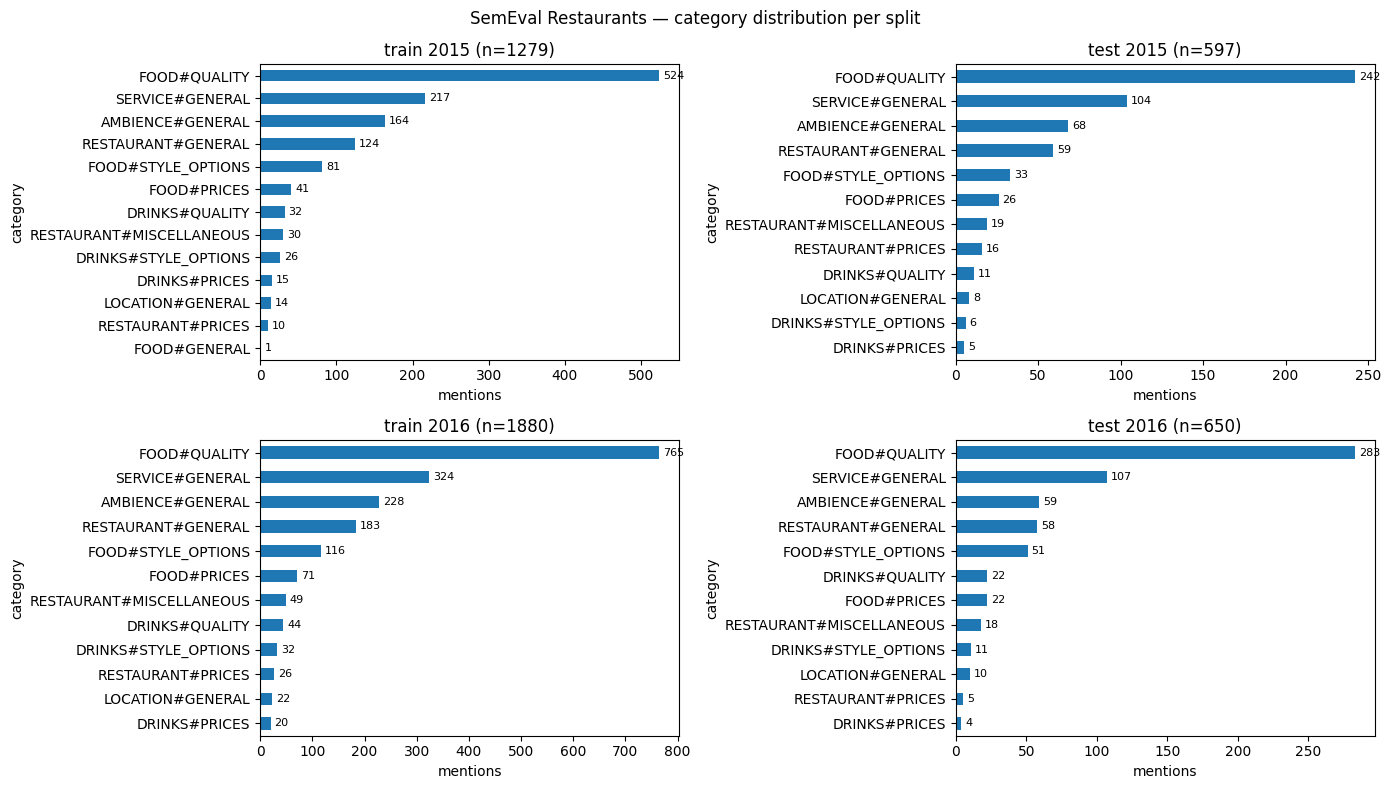

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
for ax, (split, year) in zip(axes.flat, [(s, y) for y in (2015, 2016) for s in ("train", "test")]):
    sub = data[(data.year == year) & (data.split == split)]
    counts = sub.category.value_counts().sort_values(ascending=True)
    counts.plot.barh(ax=ax)
    ax.set_title(f"{split} {year} (n={len(sub)})")
    ax.set_xlabel("mentions")
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts) * 0.01, i, str(v), va="center", fontsize=8)
fig.suptitle("SemEval Restaurants — category distribution per split")
fig.tight_layout()

## Train-vs-test category overlap

In [4]:
for year in (2015, 2016):
    train_cats = set(data[(data.year == year) & (data.split == "train")].category)
    test_cats  = set(data[(data.year == year) & (data.split == "test")].category)
    only_train = sorted(train_cats - test_cats)
    only_test  = sorted(test_cats - train_cats)
    print(f"=== {year} ===")
    print(f"  |train cats| = {len(train_cats)}, |test cats| = {len(test_cats)}")
    print(f"  only in train ({len(only_train)}): {only_train}")
    print(f"  only in test  ({len(only_test)}):  {only_test}")
    if only_test:
        print("  ! test contains categories absent from train -- XCat will degenerate for these mentions")
    else:
        print("  OK: every test mention's category is covered by train")


=== 2015 ===
  |train cats| = 13, |test cats| = 12
  only in train (1): ['FOOD#GENERAL']
  only in test  (0):  []
  OK: every test mention's category is covered by train
=== 2016 ===
  |train cats| = 12, |test cats| = 12
  only in train (0): []
  only in test  (0):  []
  OK: every test mention's category is covered by train


## Per-mention XCat neighbourhood size

Train mentions see `|train_cat| − 1` neighbours (self excluded), test mentions `|train_cat|`. Dashed line marks `K_DEGEN`.

In [5]:
rows = []
for year in (2015, 2016):
    train_counts = data[(data.year == year) & (data.split == "train")].category.value_counts()
    for cat in sorted(set(data[data.year == year].category)):
        n_train = int(train_counts.get(cat, 0))
        rows.append({
            "year": year,
            "category": cat,
            "train_mentions": n_train,
            "train_mention_neighbours": max(n_train - 1, 0),
            "test_mention_neighbours": n_train,
            "degenerate_train": n_train - 1 < K_DEGEN,
            "degenerate_test":  n_train < K_DEGEN,
        })
nbr = pd.DataFrame(rows).sort_values(["year", "train_mentions"], ascending=[True, False])
nbr.reset_index(drop=True)


,year,category,train_mentions,train_mention_neighbours,test_mention_neighbours,degenerate_train,degenerate_test
0,2015,FOOD#QUALITY,524,523,524,False,False
1,2015,SERVICE#GENERAL,217,216,217,False,False
2,2015,AMBIENCE#GENERAL,164,163,164,False,False
3,2015,RESTAURANT#GENERAL,124,123,124,False,False
4,2015,FOOD#STYLE_OPTIONS,81,80,81,False,False
5,2015,FOOD#PRICES,41,40,41,False,False
6,2015,DRINKS#QUALITY,32,31,32,False,False
7,2015,RESTAURANT#MISCELLANEOUS,30,29,30,False,False
8,2015,DRINKS#STYLE_OPTIONS,26,25,26,False,False
9,2015,DRINKS#PRICES,15,14,15,False,False


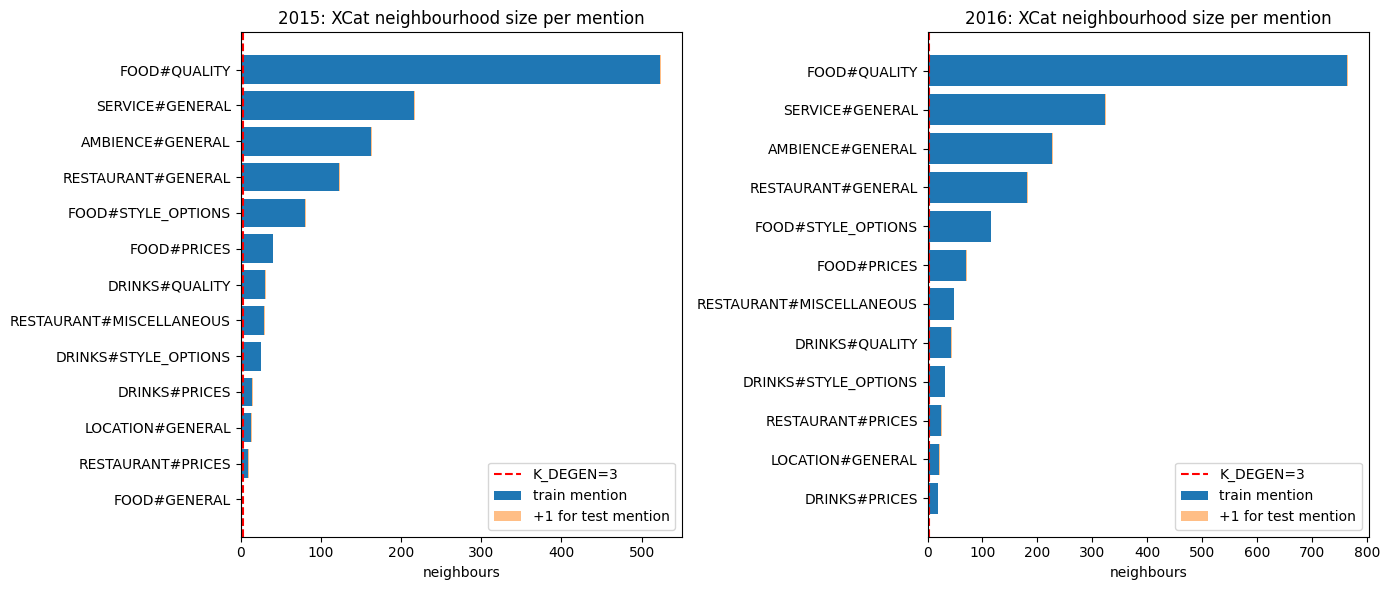

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
for ax, year in zip(axes, (2015, 2016)):
    sub = nbr[nbr.year == year].sort_values("train_mention_neighbours")
    ax.barh(sub.category, sub.train_mention_neighbours, label="train mention")
    ax.barh(sub.category, sub.test_mention_neighbours - sub.train_mention_neighbours,
            left=sub.train_mention_neighbours, color="C1", alpha=0.5,
            label="+1 for test mention")
    ax.axvline(K_DEGEN, color="red", linestyle="--", label=f"K_DEGEN={K_DEGEN}")
    ax.set_title(f"{year}: XCat neighbourhood size per mention")
    ax.set_xlabel("neighbours")
    ax.legend(loc="lower right")
fig.tight_layout()


## Degeneracy flags

In [7]:
degen = nbr[nbr.degenerate_train | nbr.degenerate_test].copy()
if degen.empty:
    print(f"No categories degenerate below K_DEGEN={K_DEGEN} in either split.")
else:
    print(f"Degenerate categories (< {K_DEGEN} neighbours):")
    for _, r in degen.iterrows():
        flags = []
        if r.degenerate_train:
            flags.append(f"train-mention nbrs={int(r.train_mention_neighbours)}")
        if r.degenerate_test:
            flags.append(f"test-mention nbrs={int(r.test_mention_neighbours)}")
        print(f"  {r.year} {r.category:25s} ({int(r.train_mentions)} train mentions) -- {', '.join(flags)}")


Degenerate categories (< 3 neighbours):
  2015 FOOD#GENERAL              (1 train mentions) -- train-mention nbrs=0, test-mention nbrs=1


## Polarity composition per category

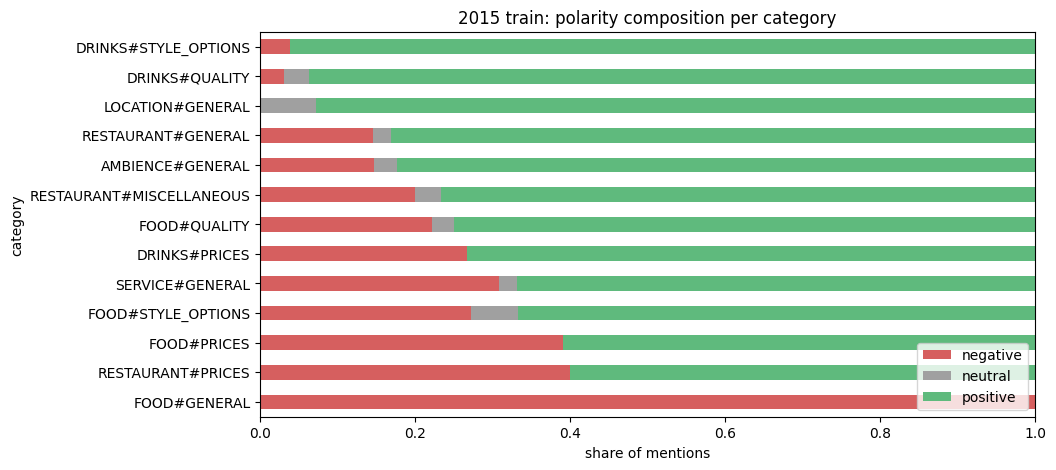

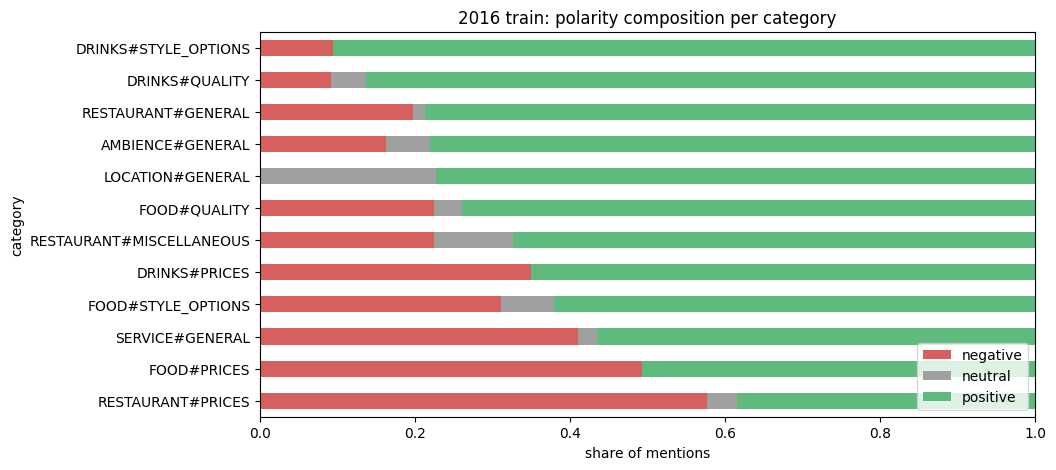

In [8]:
for year in (2015, 2016):
    sub = data[(data.year == year) & (data.split == "train")]
    pol_per_cat = (
        sub.groupby(["category", "polarity"]).size()
        .unstack(fill_value=0)
        .reindex(columns=["negative", "neutral", "positive"], fill_value=0)
    )
    pol_per_cat = pol_per_cat.div(pol_per_cat.sum(axis=1), axis=0)
    pol_per_cat = pol_per_cat.sort_values("positive")

    ax = pol_per_cat.plot.barh(stacked=True, figsize=(10, 5),
                                color=["#d65f5f", "#a0a0a0", "#5fba7d"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("share of mentions")
    ax.set_title(f"{year} train: polarity composition per category")
    ax.legend(loc="lower right")
    plt.show()


## Per-row category lookup

In [9]:
for split, year, stem in SPLITS:
    sub = data[(data.split == split) & (data.year == year)].sort_values("row").head(10)
    print(f"--- {stem}.txt.cat (first 10 rows) ---")
    for _, r in sub.iterrows():
        print(f"  row {r.row:>3}  target={r.target!r:25s}  polarity={r.polarity:>8}  category={r.category}")
    print()


--- train2015restaurant.txt.cat (first 10 rows) ---
  row   0  target='place'                    polarity=negative  category=RESTAURANT#GENERAL
  row   1  target='staff'                    polarity=negative  category=SERVICE#GENERAL
  row   2  target='food'                     polarity=negative  category=FOOD#QUALITY
  row   3  target='portions'                 polarity=negative  category=FOOD#STYLE_OPTIONS
  row   4  target='place'                    polarity=negative  category=RESTAURANT#GENERAL
  row   5  target='food'                     polarity=positive  category=FOOD#QUALITY
  row   6  target='Saul'                     polarity=positive  category=RESTAURANT#GENERAL
  row   7  target='foie gras terrine with figs'  polarity=positive  category=FOOD#QUALITY
  row   8  target='duck confit'              polarity=positive  category=FOOD#QUALITY
  row   9  target='wine list'                polarity=positive  category=DRINKS#STYLE_OPTIONS

--- test2015restaurant.txt.cat (first 10 rows) -